# Hyperparameter Grid Search

This notebook contains code to perform grid searches over hyperparameter combinations for the various training algorithms tested for this project

In [30]:
%load_ext autoreload
%autoreload 2

import warnings
import logging
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from data import build_random_dag, generate_random_dataset, load_sachs
from reporting import plot_hyperparam_sensitivity, print_summary, METRIC_COLUMNS
from training import grid_search

logging.getLogger('castle').setLevel(logging.WARNING)
warnings.filterwarnings('ignore')

SEED = 42

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
def _marginal(results_df, param_grid, row_param, col_param):
    """Average metrics over all parameters except the given pair."""
    other = [p for p in param_grid if p not in (row_param, col_param)]
    return (
        results_df.groupby([row_param, col_param])[METRIC_COLUMNS].mean().reset_index()
        if other else results_df
    )


def plot_scatter(results_df, param_grid):
    """Precision–Recall scatter for all combinations.
    First two params drive color/marker; any extras are averaged out.
    Bubble size is proportional to SHD (smaller = better)."""
    param_names = list(param_grid.keys())
    p0, p1 = param_names[0], param_names[1]
    df     = _marginal(results_df, param_grid, p0, p1)
    p0_vals = sorted(df[p0].unique())
    p1_vals = sorted(df[p1].unique())
    colors  = plt.cm.tab10(np.linspace(0, 1, len(p0_vals)))
    markers = ["o", "s", "^", "D", "v", "P"]
    fig, ax = plt.subplots(figsize=(8, 6))
    for p0_idx, p0_val in enumerate(p0_vals):
        for _, row in df[df[p0] == p0_val].iterrows():
            p1_idx = p1_vals.index(row[p1])
            ax.scatter(row["precision"], row["recall"],
                       s=row["shd"] * 6 + 20,
                       color=colors[p0_idx],
                       marker=markers[p1_idx % len(markers)],
                       alpha=0.8, edgecolors="white", linewidths=0.5)
            ax.annotate(f"({p0_val},{row[p1]})",
                        (row["precision"], row["recall"]),
                        textcoords="offset points", xytext=(5, 3), fontsize=7, alpha=0.7)
    other = [p for p in param_names if p not in (p0, p1)]
    extra = f"  (avg over: {', '.join(other)})" if other else ""
    ax.set_title(f"Precision–Recall: {p0} × {p1}{extra}\n(bubble ∝ SHD)", fontsize=12)
    ax.set_xlabel("Precision"); ax.set_ylabel("Recall")
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color="grey", lw=0.5, ls="--")
    ax.axvline(0.5, color="grey", lw=0.5, ls="--")
    ax.grid(alpha=0.3)
    handles = [mpatches.Patch(color=colors[i], label=f"{p0}={v}") for i, v in enumerate(p0_vals)]
    ax.legend(handles=handles, title=p0, fontsize=8, loc="lower right")
    fig.tight_layout()
    plt.show()


def search_and_report(df, gt_dag, param_grid, algorithm: str):
    best_result, results_df = grid_search(df, algorithm, param_grid, gt_dag)
    best_params = results_df.loc[results_df["shd"].idxmin(), list(param_grid.keys())].to_dict()
    print(f"Best SHD: {results_df['shd'].min():.0f}  params: {best_params}")
    print(results_df)

    plot_hyperparam_sensitivity(results_df)
    # plot_scatter(results_df, param_grid)
    print_summary(results_df)


## Sachs et al.

This section of the notebook contains hyper-parameter search for the Sachs et al. protein dataset (11 variables)

In [32]:
sachs_df, sachs_dag  = load_sachs()
print(f"Sachs: {sachs_df.shape[0]} samples, {sachs_df.shape[1]} nodes, {len(sachs_dag.edges())} true edges")


Sachs: 11672 samples, 11 nodes, 20 true edges


### NOTEARS

Grid search over the following NOTEARS hyperparameters:

| Parameter | Role |
|-----------|------|
| `lambda1` | L1 penalty — higher values push edge weights toward zero (sparser graphs) |
| `w_threshold` | Post-optimisation cutoff — edges with `\|weight\| < w_threshold` are pruned |

In [33]:
SACHS_PARAM_GRID = {
    "lambda1":     [0.01, 0.05, 0.1, 0.2, 0.5],
    "w_threshold": [0.1, 0.2, 0.3, 0.5],
}

best_result_sachs, results_df_sachs = grid_search(sachs_df, "notears", SACHS_PARAM_GRID, sachs_dag)
best_params_sachs = results_df_sachs.loc[results_df_sachs["shd"].idxmin(), list(SACHS_PARAM_GRID.keys())].to_dict()
print(f"Best SHD: {results_df_sachs['shd'].min():.0f}  params: {best_params_sachs}")
results_df_sachs

2026-06-28 17:00:22,392 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=11672, d=11, iter_=100, h_=1e-08, rho_=10000000000000000


Grid: 5 × 4 = 20 combinations



2026-06-28 17:00:23,779 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=2.495e+00, loss=543643.397, rho=1.0e+00
2026-06-28 17:00:23,854 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.492e+00, loss=259284.164, rho=1.0e+00
2026-06-28 17:00:24,085 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.464e+00, loss=259312.179, rho=1.0e+01
2026-06-28 17:00:24,610 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.251e+00, loss=259592.326, rho=1.0e+02
2026-06-28 17:00:25,235 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradie

Best SHD: 20  params: {'lambda1': 0.01, 'w_threshold': 0.5}


,lambda1,w_threshold,n_learned,shd,precision,recall,f1,tp,fp,fn,reversed
0,0.01,0.1,27,26,0.259259,0.35,0.297872,7,13,6,7
1,0.01,0.2,19,22,0.315789,0.30,0.307692,6,8,9,5
2,0.01,0.3,18,22,0.333333,0.30,0.315789,6,8,10,4
3,0.01,0.5,13,20,0.384615,0.25,0.303030,5,5,12,3
4,0.05,0.1,24,26,0.250000,0.30,0.272727,6,12,8,6
5,0.05,0.2,19,22,0.315789,0.30,0.307692,6,8,9,5
6,0.05,0.3,18,22,0.333333,0.30,0.315789,6,8,10,4
7,0.05,0.5,12,20,0.416667,0.25,0.312500,5,5,13,2
8,0.10,0.1,24,26,0.250000,0.30,0.272727,6,12,8,6
9,0.10,0.2,19,22,0.315789,0.30,0.307692,6,8,9,5


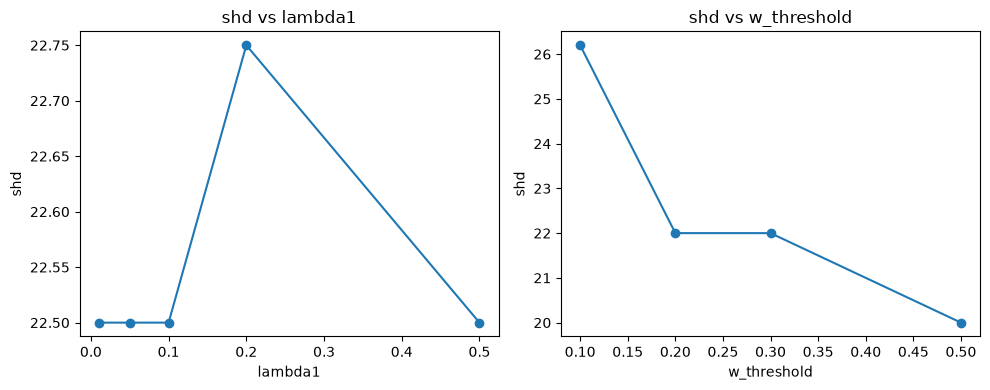

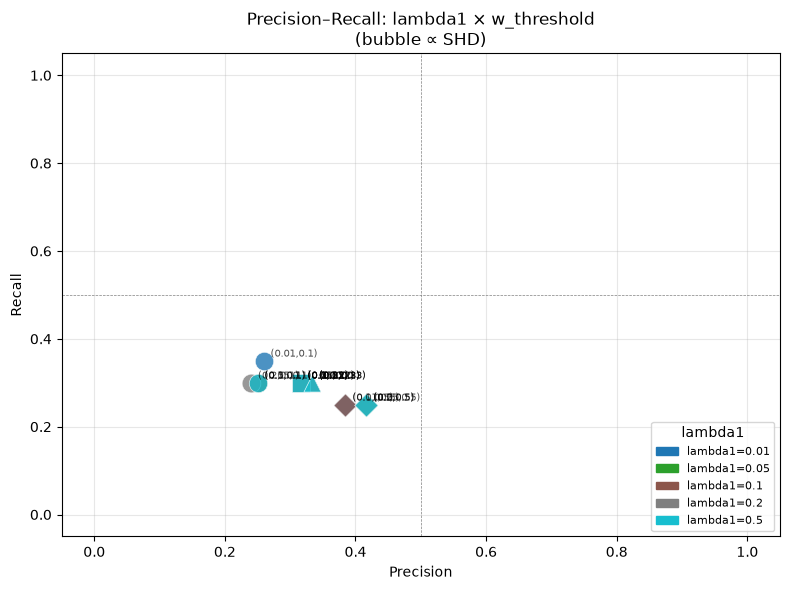

Top 5 combinations by shd
 lambda1  w_threshold    f1  precision  recall  shd  n_learned
    0.01          0.5 0.303      0.385    0.25   20         13
    0.05          0.5 0.312      0.417    0.25   20         12
    0.20          0.5 0.312      0.417    0.25   20         12
    0.10          0.5 0.303      0.385    0.25   20         13
    0.50          0.5 0.312      0.417    0.25   20         12

Recommended: lambda1=0.01, w_threshold=0.5
  F1=0.303  Precision=0.385  Recall=0.250  SHD=20


In [35]:
plot_hyperparam_sensitivity(results_df_sachs)
plot_scatter(results_df_sachs, SACHS_PARAM_GRID)
print_summary(results_df_sachs)


### PC

Grid search over the following PC hyperparameters on the real Sachs et al. dataset:

| Parameter | Role |
|-----------|------|
| `ci_test` | Conditional independence test (e.g. `"pearsonr"` for continuous Gaussian data, `"chi_square"` / `"g_sq"` for discrete) |
| `significance_level` | Alpha threshold — lower values yield sparser graphs (fewer edges kept after CI tests) |
| `max_cond_vars` | Maximum conditioning-set size — limits the depth of the skeleton-finding phase; `None` = no limit |

Grid: 1 × 6 × 4 = 24 combinations



2026-06-28 17:58:15,216 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-28 17:58:18,798 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-28 17:58:23,970 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-28 17:58:30,261 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-28 17:58:32,385 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discove

Best SHD: 30  params: {'ci_test': 'pearsonr', 'significance_level': 0.001, 'max_cond_vars': nan}
     ci_test  significance_level  max_cond_vars  n_learned  shd  precision  \
0   pearsonr               0.001            2.0         36   35   0.250000   
1   pearsonr               0.001            3.0         29   31   0.241379   
2   pearsonr               0.001            4.0         29   31   0.241379   
3   pearsonr               0.001            NaN         28   30   0.250000   
4   pearsonr               0.005            2.0         36   35   0.250000   
5   pearsonr               0.005            3.0         36   35   0.250000   
6   pearsonr               0.005            4.0         30   33   0.166667   
7   pearsonr               0.005            NaN         31   33   0.225806   
8   pearsonr               0.010            2.0         46   42   0.260870   
9   pearsonr               0.010            3.0         36   36   0.222222   
10  pearsonr               0.010            4

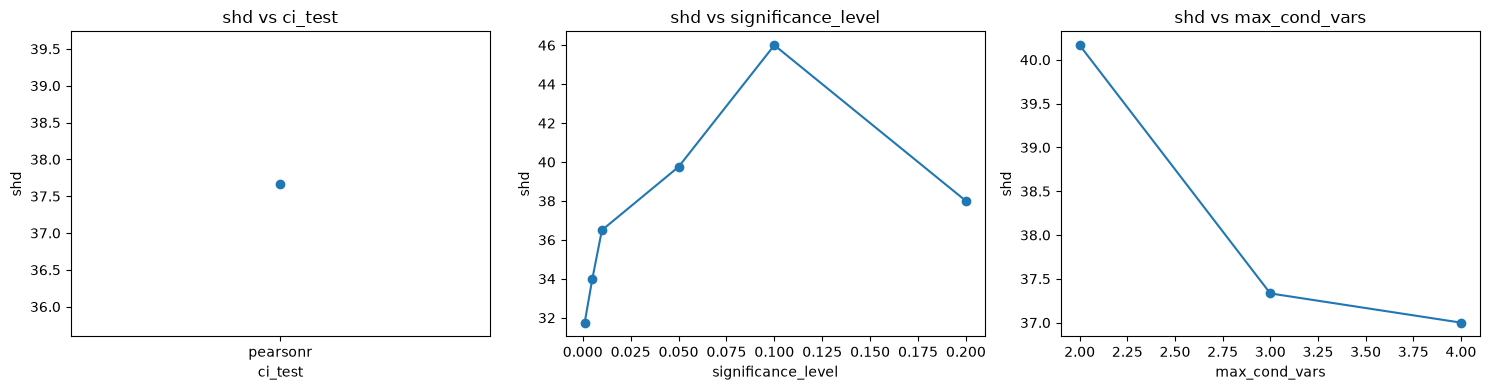

Top 5 combinations by shd
 ci_test  significance_level  max_cond_vars    f1  precision  recall  shd  n_learned
pearsonr               0.001            NaN 0.275      0.250   0.304   30         28
pearsonr               0.001            3.0 0.269      0.241   0.304   31         29
pearsonr               0.001            4.0 0.269      0.241   0.304   31         29
pearsonr               0.010            NaN 0.286      0.250   0.333   32         32
pearsonr               0.005            4.0 0.192      0.167   0.227   33         30

Recommended: ci_test=pearsonr, significance_level=0.001, max_cond_vars=nan
  F1=0.275  Precision=0.250  Recall=0.304  SHD=30


In [48]:
PC_PARAM_GRID = {
    "ci_test":            ["pearsonr"],
    "significance_level": [0.001, 0.005, 0.01, 0.05, 0.1, 0.2],
    "max_cond_vars":      [2, 3, 4, None],
}
search_and_report(sachs_df, sachs_dag, PC_PARAM_GRID, "pc")

### FGES

Grid search over the following GES hyperparameters on the real Sachs et al. dataset:

| Parameter | Role | Values |
|-----------|------|--------|
| `method` | BIC scoring variant | `scatter` (covariance-based), `r2` (adjusted R²) |

In [43]:
FGES_SACHS_PARAM_GRID = {
    "method": ["scatter", "r2"],
}

best_result_fges_sachs, results_df_fges_sachs = grid_search(sachs_df, "fges", FGES_SACHS_PARAM_GRID, sachs_dag)
best_params_fges_sachs = results_df_fges_sachs.loc[
    results_df_fges_sachs["shd"].idxmin(), list(FGES_SACHS_PARAM_GRID.keys())
].to_dict()
print(f"Best SHD: {results_df_fges_sachs['shd'].min():.0f}  params: {best_params_fges_sachs}")
results_df_fges_sachs

Grid: 2 = 2 combinations

Best SHD: 26  params: {'method': 'r2'}


,method,n_learned,shd,precision,recall,f1,tp,fp,fn,reversed
0,scatter,35,33,0.228571,0.363636,0.280702,8,19,6,8
1,r2,20,26,0.363636,0.285714,0.320000,8,6,12,8


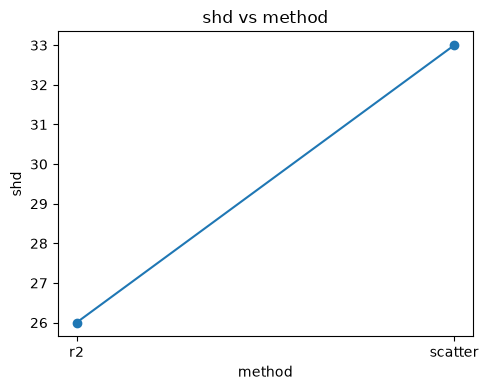

Top 5 combinations by shd
 method    f1  precision  recall  shd  n_learned
     r2 0.320      0.364   0.286   26         20
scatter 0.281      0.229   0.364   33         35

Recommended: method=r2
  F1=0.320  Precision=0.364  Recall=0.286  SHD=26


In [ ]:
plot_hyperparam_sensitivity(results_df_fges_sachs)
print_summary(results_df_fges_sachs)


## Cancer

This section of the notebook contains hyper-parameter search for the cancer dataset (5 variables)


In [ ]:
from data import load_cancer

cancer_df, cancer_dag = load_cancer(1000)
print(f"Cancer: {cancer_df.shape[0]} samples, {cancer_df.shape[1]} nodes, {len(cancer_dag.edges())} true edges")


### PC

Grid search over the following PC hyperparameters:

| Parameter | Role |
|-----------|------|
| `ci_test` | Conditional independence test (e.g. `"pearsonr"` for continuous Gaussian data, `"chi_square"` / `"g_sq"` for discrete) |
| `significance_level` | Alpha threshold — lower values yield sparser graphs (fewer edges kept after CI tests) |
| `max_cond_vars` | Maximum conditioning-set size — limits the depth of the skeleton-finding phase; `None` = no limit |

In [ ]:
PC_PARAM_GRID = {
    "ci_test":            ["pearsonr"],
    "significance_level": [0.001, 0.005, 0.01, 0.05, 0.1, 0.2],
    "max_cond_vars":      [2, 3, 4, None],
}
search_and_report(cancer_df, cancer_dag, PC_PARAM_GRID, "pc")

## NOTEARS grid search over random DAG
(deprecated i dont think i want to work on a randomly generated graph tbh)

Grid search over the following NOTEARS hyperparameters:

| Parameter | Role |
|-----------|------|
| `lambda1` | L1 penalty — higher values push edge weights toward zero (sparser graphs) |
| `w_threshold` | Post-optimisation cutoff — edges with `|weight| < w_threshold` are pruned |
| `loss_type` | |
| `h_tol` | |
| `rho_max` | |


Training is done on a randomly generated dataset from a randomly generated DAG

In [ ]:

# N_NODES   = 15
# N_SAMPLES = 600
# EDGE_PROB = 0.25

# PARAM_GRID = {
#     "lambda1":     [0.01, 0.05, 0.1, 0.2, 0.5],
#     "w_threshold": [0.1, 0.2, 0.3, 0.5],
# }

# dag = build_random_dag(N_NODES, edge_prob=EDGE_PROB, seed=SEED)
# df  = generate_random_dataset(
#     n_features=N_NODES, n_samples=N_SAMPLES,
#     ground_truth_dag=dag, seed=SEED,
# )

# print(f"DAG:  {N_NODES} nodes, {len(dag.edges())} true edges, {N_SAMPLES} samples")
# best_result, results_df = grid_search(df, "notears", PARAM_GRID, dag)

# best_params = results_df.loc[results_df["shd"].idxmin(), list(PARAM_GRID.keys())].to_dict()
# print(f"Best SHD: {results_df['shd'].min():.0f}  params: {best_params}")
# results_df

### Results

In [ ]:
# plot_heatmaps(results_df, PARAM_GRID)

In [ ]:
# plot_line_profiles(results_df, PARAM_GRID, best_params)

In [ ]:
# plot_scatter(results_df, PARAM_GRID)

In [ ]:
# print_summary(results_df, PARAM_GRID)